# 02. EDA (탐색적 데이터 분석)
- 클래스 / 부위 분포 시각화
- 이미지 품질 검사 (해상도 · 밝기 · 손상)
- 클래스별 샘플 이미지 시각화
- 정규화 기준값 (mean / std) 계산 → config.yaml 반영

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

plt.rcParams['font.family'] = 'Malgun Gothic'   # Windows
# plt.rcParams['font.family'] = 'AppleGothic'   # Mac 사용 시 주석 해제
plt.rcParams['axes.unicode_minus'] = False

print('라이브러리 로드 완료')

라이브러리 로드 완료


## 1. 경로 설정 및 데이터 로드

In [2]:
# 노트북이 notebooks/ 안에 있으므로 ROOT는 한 단계 위
ROOT      = Path('..')
PROCESSED = ROOT / 'data/processed'
FIG_DIR   = ROOT / 'outputs/figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 01_data_collection.ipynb에서 생성한 CSV 불러오기
df = pd.read_csv(PROCESSED / 'dataset.csv')

# sub_img_path가 있으면 우선 사용, 없으면 img_path 사용
target_col = 'sub_img_path' if 'sub_img_path' in df.columns else 'img_path'
print(f'이미지 경로 컬럼: {target_col}')

LESION_MAP = {
    'A1': 'A1 구진/플라크',
    'A2': 'A2 비듬/각질',
    'A3': 'A3 태선화/색소',
    'A4': 'A4 농포/여드름',
    'A5': 'A5 미란/궤양',
    'A6': 'A6 결절/종괴',
    'A7': 'A7 무증상(정상)',
}
df['lesion_name'] = df['lesion'].map(LESION_MAP)

print(f'데이터 로드 완료: {len(df):,}장')
df.head()

이미지 경로 컬럼: sub_img_path
데이터 로드 완료: 35,000장


,json_path,img_file,species,lesion,region,path_type,hash,split,img_path,sub_img_path,lesion_name
0,..\data\raw\Training\TL02\반려견\피부\일반카메라\유증상\A4_...,IMG_D_A4_193221.jpg,D,A4,H,유증상,f2a9f7b20f0e5dd442c80b31a0525162,train,..\data\raw\Training\TL02\반려견\피부\일반카메라\유증상\A4_...,..\data\raw_sub\IMG_D_A4_193221.jpg,A4 농포/여드름
1,..\data\raw\Training\TL02\반려견\피부\일반카메라\유증상\A3_...,IMG_D_A3_153264.jpg,D,A3,A,유증상,227315c76d9548182c437c53d7d5946d,train,..\data\raw\Training\TL02\반려견\피부\일반카메라\유증상\A3_...,..\data\raw_sub\IMG_D_A3_153264.jpg,A3 태선화/색소
2,..\data\raw\Validation\VL01\반려견\피부\일반카메라\유증상\A...,IMG_D_A2_465463.jpg,D,A2,A,유증상,45f919aae8f4fc71c2672b9753e22705,train,..\data\raw\Validation\VL01\반려견\피부\일반카메라\유증상\A...,..\data\raw_sub\IMG_D_A2_465463.jpg,A2 비듬/각질
3,..\data\raw\Training\TL01\반려견\피부\일반카메라\유증상\A1_...,IMG_D_A1_018945.jpg,D,A1,B,유증상,aad2e0834104cfd51db5f7fdae87d14a,train,..\data\raw\Training\TL01\반려견\피부\일반카메라\유증상\A1_...,..\data\raw_sub\IMG_D_A1_018945.jpg,A1 구진/플라크
4,..\data\raw\Training\TL02\반려견\피부\일반카메라\유증상\A4_...,IMG_D_A4_195351.jpg,D,A4,L,유증상,e3a4cf0980eb5477e74a4deec99b7923,train,..\data\raw\Training\TL02\반려견\피부\일반카메라\유증상\A4_...,..\data\raw_sub\IMG_D_A4_195351.jpg,A4 농포/여드름


## 2. 클래스 / 부위 분포 시각화

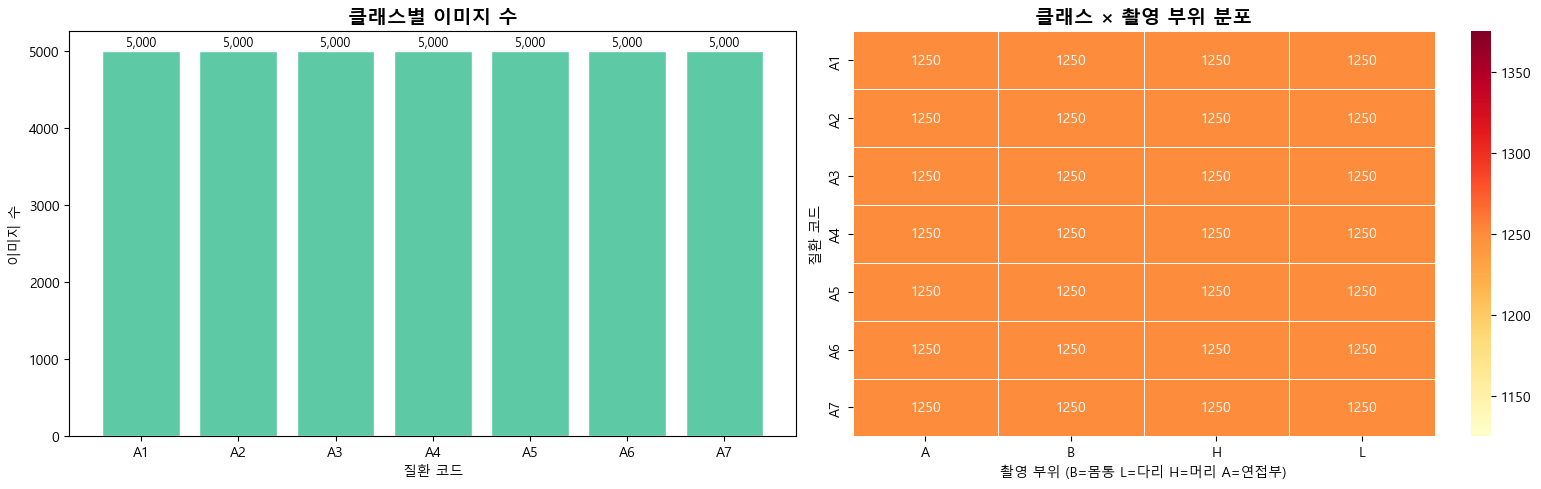

저장 완료 → outputs/figures/class_region_dist.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── 클래스별 이미지 수 막대그래프 ──
class_counts = df['lesion'].value_counts().sort_index()
bars = axes[0].bar(class_counts.index, class_counts.values, color='#5DCAA5', edgecolor='white')
axes[0].set_title('클래스별 이미지 수', fontsize=14, fontweight='bold')
axes[0].set_xlabel('질환 코드')
axes[0].set_ylabel('이미지 수')
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# ── 클래스 × 부위 히트맵 ──
pivot = df.groupby(['lesion', 'region']).size().unstack(fill_value=0)
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1], linewidths=0.5)
axes[1].set_title('클래스 × 촬영 부위 분포', fontsize=14, fontweight='bold')
axes[1].set_xlabel('촬영 부위 (B=몸통 L=다리 H=머리 A=연접부)')
axes[1].set_ylabel('질환 코드')

plt.tight_layout()
plt.savefig(FIG_DIR / 'class_region_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료 → outputs/figures/class_region_dist.png')

## 3. 이미지 품질 검사

In [4]:
def check_quality(img_path):
    """이미지 1장 품질 검사 → 결과 문자열 반환."""
    try:
        # 경로가 비어있거나 파일이 존재하지 않으면 제거
        if pd.isna(img_path) or not os.path.exists(img_path):
            return '파일없음'
        img    = Image.open(img_path).convert('RGB')
        w, h   = img.size
        arr    = np.array(img)
        bright = arr.mean() # 전체 픽셀 평균 밝기 (0~255)
        std    = arr.std()  # 픽셀값 표준편차 → 낮을수록 단색에 가까움

        # 가로 또는 세로가 100px 미만이면 CNN 입력(224x224)에 부적합
        if w < 100 or h < 100:            return '저해상도'
        # 평균 밝기가 30 미만이면 너무 어두운 사진 (피부 병변 식별 불가)
        # 평균 밝기가 220 초과면 너무 밝은 사진 (노출 과다, 피부 정보 손실)
        if bright < 30 or bright > 220:   return '밝기이상'
        # 표준편차가 10 미만이면 단색에 가까운 사진
        # → 렌즈 막힘, 파일 손상, 또는 피부가 아닌 배경만 찍힌 경우
        if std < 10:                      return '단색손상'
        return 'OK'
    except Exception:
        # 파일 자체를 열 수 없는 경우 (손상된 jpg 등)
        return '파일손상'

with ThreadPoolExecutor(max_workers=8) as exe:
    quality = list(tqdm(exe.map(check_quality, df[target_col]), total=len(df), desc='품질 검사'))

df['quality'] = quality
q_counts = df['quality'].value_counts()

print('\n[품질 검사 결과]')
print(q_counts)
print(f'\nOK 비율: {q_counts.get("OK", 0) / len(df) * 100:.1f}%')
print('\n── README 기록용 ──')
for label, cnt in q_counts.items():
    if label != 'OK':
        print(f'  제거 대상 [{label}]: {cnt:,}장')

품질 검사: 100%|██████████| 35000/35000 [12:26<00:00, 46.87it/s]


[품질 검사 결과]
quality
OK      34987
단색손상        8
파일손상        5
Name: count, dtype: int64

OK 비율: 100.0%

── README 기록용 ──
  제거 대상 [단색손상]: 8장
  제거 대상 [파일손상]: 5장


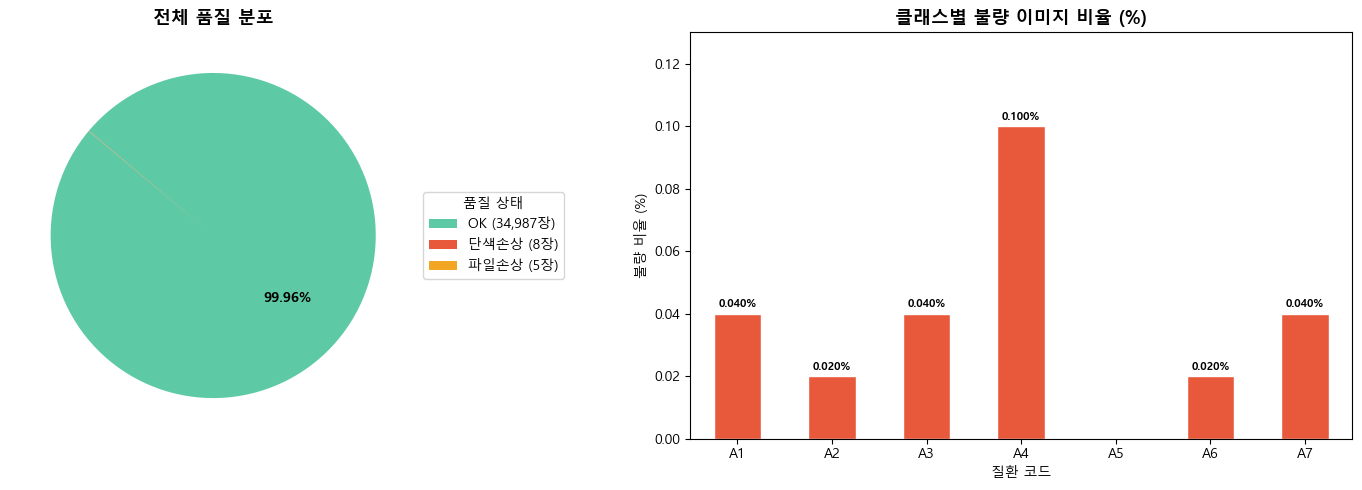

In [ ]:
# 품질 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── [1] 왼쪽: 전체 품질 분포 (Pie Chart) ──
# 0.5% 미만의 극소수 비율은 파이 차트 내에 글자를 표시하지 않도록 커스텀 함수 정의
def dynamic_autopct(pct):
    return f'{pct:.2f}%' if pct > 0.5 else ''

# 파이 차트 그리기 (labels=None으로 차트 주변 글자 원천 차단)
# autopct가 활성화되었으므로 반환값을 3개(wedges, texts, autotexts)로 온전히 받습니다.
wedges, texts, autotexts = axes[0].pie(
    q_counts.values, 
    labels=None,                 # 차트 표면에 레이블을 붙이지 않음 (텍스트 겹침 방지)
    autopct=dynamic_autopct,     # 99.96%처럼 소수점 둘째 자리까지 깔끔하게 표현
    startangle=140,              # 보기 좋은 시작 각도
    pctdistance=0.6,             # 수치 표시 위치 (중심 기준)
    colors=['#5DCAA5', '#E8593C', '#F2A623', '#378ADD', '#888780'][:len(q_counts)]
)

# 차트 내부 수치 텍스트(autotexts) 가독성 높이기 (글씨 크기 및 굵기 조절)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

# 차트 바깥쪽에 깔끔하게 범례(Legend) 배치
axes[0].legend(
    wedges, 
    [f'{label} ({cnt:,}장)' for label, cnt in q_counts.items()], # 레이블명과 장수 표기
    title="품질 상태",
    loc="center left",
    bbox_to_anchor=(1.0, 0, 0.5, 1) # 파이 차트 우측 바깥 영역으로 범례 밀어내기
)
axes[0].set_title('전체 품질 분포', fontweight='bold', fontsize=13)
axes[0].set_ylabel('')


# ── [2] 오른쪽: 클래스별 불량 이미지 비율 (Bar Chart) ──
bad_ratio = (
    df[df['quality'] != 'OK'].groupby('lesion').size() /
    df.groupby('lesion').size() * 100
).fillna(0)

# 모든 클래스(A1~A7)가 누락 없이 X축에 나오도록 재정렬
all_classes = sorted(df['lesion'].unique())
bad_ratio = bad_ratio.reindex(all_classes, fill_value=0)

bad_ratio.plot(kind='bar', ax=axes[1], color='#E8593C', edgecolor='white')
axes[1].set_title('클래스별 불량 이미지 비율 (%)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('질환 코드')
axes[1].set_ylabel('불량 비율 (%)')
axes[1].tick_params(axis='x', rotation=0)

# Y축 범위 최적화: 불량률이 너무 낮으므로 최대 불량률의 1.2배 크기로 설정하여 막대가 보이도록 조절
max_val = bad_ratio.max()
if max_val > 0:
    axes[1].set_ylim(0, max_val * 1.3) # 텍스트 공간 확보를 위해 1.3배로 수정
    # 막대 상단에 실제 퍼센트 수치 텍스트 표시
    for p in axes[1].patches:
        height = p.get_height()
        if height > 0:
            axes[1].text(
                p.get_x() + p.get_width()/2., height + (max_val * 0.02),
                f'{height:.3f}%', ha="center", fontsize=8, fontweight='bold'
            )
else:
    axes[1].set_ylim(0, 1) # 불량이 아예 0장일 때의 기본 예외 처리

plt.tight_layout()
plt.savefig(FIG_DIR / 'quality_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 불량 데이터 제거 및 정제 CSV 저장

In [ ]:
df_cleaned = df[df['quality'] == 'OK'].copy()

print(f'정제 전: {len(df):,}장')
print(f'정제 후: {len(df_cleaned):,}장  (제거: {len(df) - len(df_cleaned):,}장)')

# dataset.csv와 별도로 저장 → 이 파일 기준으로 전처리 진행
df_cleaned.to_csv(PROCESSED / 'dataset_cleaned.csv', index=False)
print("\n저장 완료 → data/processed/dataset_cleaned.csv")

정제 전: 35,000장
정제 후: 34,987장  (제거: 13장)

저장 완료 → data/processed/dataset_cleaned.csv


## 5. 해상도 분포 확인

해상도 측정: 100%|██████████| 2000/2000 [00:00<00:00, 12030.61it/s]


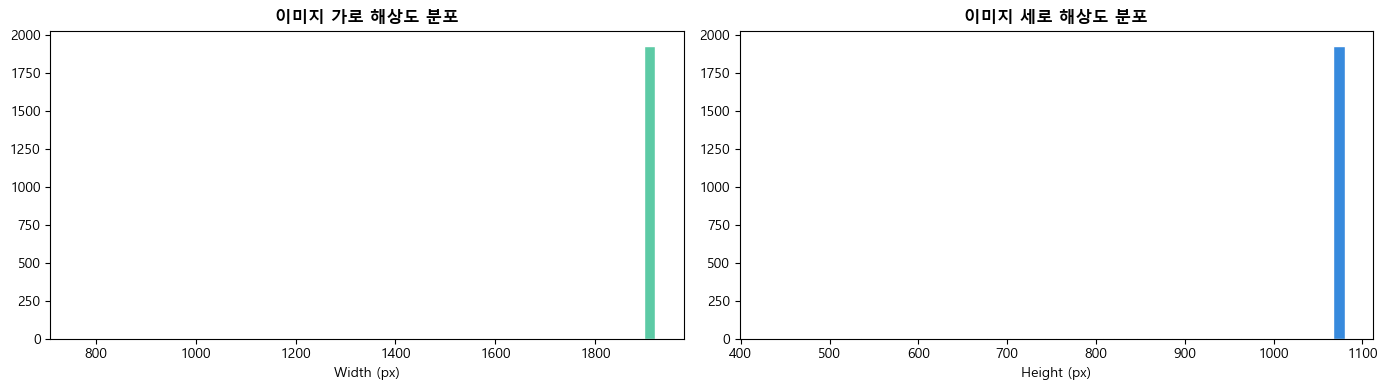

평균 해상도: 1904 × 1071 px


In [10]:
def get_size(img_path):
    try:
        return Image.open(img_path).size
    except:
        return (0, 0)

sample_ok = df_cleaned.sample(min(2000, len(df_cleaned)), random_state=42)

with ThreadPoolExecutor(max_workers=8) as exe:
    sizes = list(tqdm(exe.map(get_size, sample_ok[target_col]), total=len(sample_ok), desc='해상도 측정'))

widths  = [s[0] for s in sizes if s[0] > 0]
heights = [s[1] for s in sizes if s[1] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(widths,  bins=50, color='#5DCAA5', edgecolor='white')
axes[0].set_title('이미지 가로 해상도 분포', fontweight='bold')
axes[0].set_xlabel('Width (px)')
axes[1].hist(heights, bins=50, color='#378ADD', edgecolor='white')
axes[1].set_title('이미지 세로 해상도 분포', fontweight='bold')
axes[1].set_xlabel('Height (px)')

plt.tight_layout()
plt.savefig(FIG_DIR / 'resolution_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'평균 해상도: {np.mean(widths):.0f} × {np.mean(heights):.0f} px')

원본 이미지의 해상도 분포를 EDA로 검증한 결과, 샘플링된 모든 데이터가 1920 × 1080의 균일한 FHD 고해상도 규격을 유지하고 있음을 확인했습니다. 데이터 해상도 불일치로 인한 모호성은 없으므로 전처리 단계에서 모든 이미지를 일괄적으로 모델 입력 크기(224 × 224 등)로 축소(Resizing)하는 파이프라인을 설계할 수 있습니다.

## 6. 클래스별 샘플 이미지 시각화

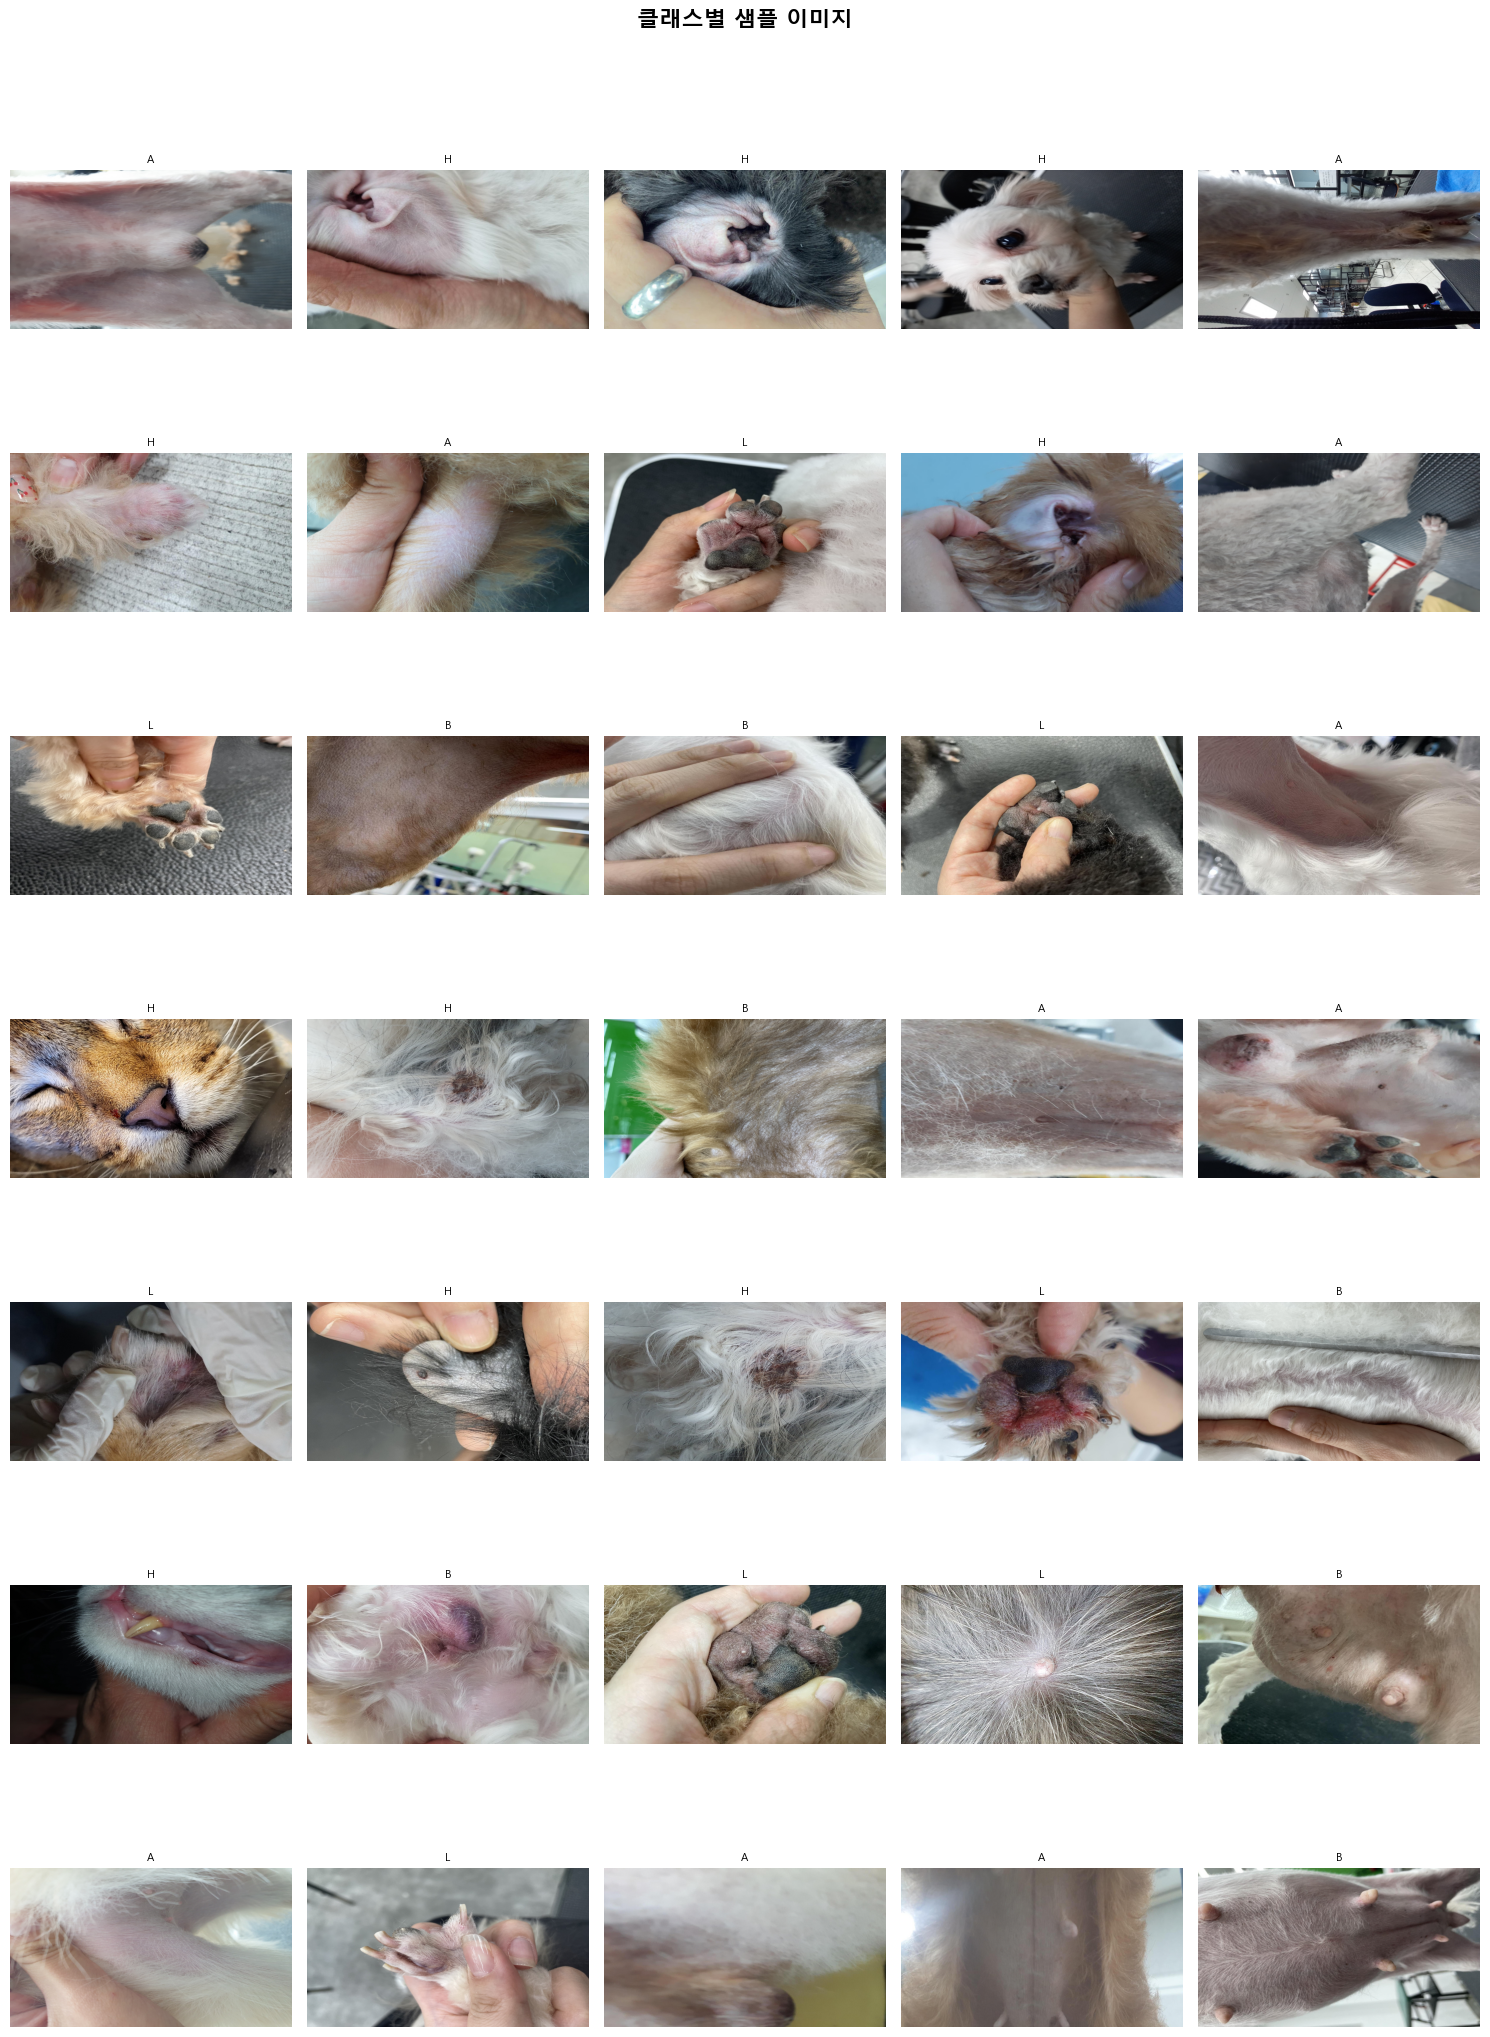

In [11]:
def show_class_samples(df, n_per_class=5):
    """클래스별 샘플 이미지를 격자로 시각화."""
    classes = sorted(df['lesion'].unique())
    fig, axes = plt.subplots(len(classes), n_per_class,
                             figsize=(n_per_class * 3, len(classes) * 3))

    for row_idx, cls in enumerate(classes):
        subset  = df[df['lesion'] == cls]
        samples = subset.sample(n=min(n_per_class, len(subset)), random_state=42)
        for col_idx in range(n_per_class):
            ax = axes[row_idx][col_idx]
            if col_idx < len(samples):
                try:
                    img = Image.open(samples.iloc[col_idx][target_col])
                    ax.imshow(img)
                    ax.set_title(samples.iloc[col_idx]['region'], fontsize=8)
                except:
                    ax.text(0.5, 0.5, '로드 실패', ha='center', va='center')
            ax.axis('off')
        axes[row_idx][0].set_ylabel(LESION_MAP.get(cls, cls), fontsize=9,
                                    rotation=0, labelpad=80, va='center')

    plt.suptitle('클래스별 샘플 이미지', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'sample_images.png', dpi=120, bbox_inches='tight')
    plt.show()

show_class_samples(df_cleaned)

## 7. 정규화 기준값 계산 (mean / std)

In [12]:
def get_channel_stats(img_path):
    """이미지 1장의 채널별 mean, std 반환."""
    try:
        arr = np.array(Image.open(img_path).resize((224, 224)).convert('RGB')) / 255.0
        return arr.mean(axis=(0, 1)), arr.std(axis=(0, 1))
    except:
        return None, None

# 정제된 데이터 기준으로 2,000장 샘플링
stat_sample = df_cleaned[target_col].sample(min(2000, len(df_cleaned)), random_state=42)

means, stds = [], []
for img_path in tqdm(stat_sample, desc='채널 통계 계산'):
    m, s = get_channel_stats(img_path)
    if m is not None:
        means.append(m)
        stds.append(s)

channel_mean = np.mean(means, axis=0).round(4).tolist()
channel_std  = np.mean(stds,  axis=0).round(4).tolist()

print('\n' + '='*50)
print('[최종 요약 및 config.yaml 설정값]')
print('='*50)
print(f'  normalize:')
print(f'    mean: {channel_mean}')
print(f'    std:  {channel_std}')
print('='*50)

채널 통계 계산: 100%|██████████| 2000/2000 [00:39<00:00, 50.03it/s]


[최종 요약 및 config.yaml 설정값]
  normalize:
    mean: [0.5616, 0.5263, 0.5056]
    std:  [0.1819, 0.1841, 0.1837]


1. 경사하강법(Optimization) 최적화 및 학습 가속화
    - 0~255의 픽셀 편차를 줄여 손실 함수의 경사고면을 균일하게 평탄화함
    - 모델이 정답(Local Minimum)을 찾는 경로를 최적화하여 수렴 속도를 수십 배 가속함

2. 가중치 편향 방지 및 기울기 소실(Vanishing Gradient) 예방
    - 대형 입력값에 의해 특정 뉴런으로 가중치 연산이 쏠리거나 미분값이 0이 되는 현상 방지
    - 입력 범위를 작은 스케일로 표준화하여 모든 뉴런이 균등하고 건강하게 학습하게 함

3. 우리 프로젝트 "특수 목적 데이터셋"에 대한 모델 최적화
    - 일반 사물 위주의 ImageNet 사전학습 기준값 대신, 반려동물 피부/구강 특성을 반영함
    - 고유 조명(스튜디오/플래시)으로 인한 밝기 장벽을 제거하고 질환 형태에 집중하게 함

## 8. EDA 최종 요약

In [13]:
print('=' * 50)
print('EDA 최종 요약 (README 기록용)')
print('=' * 50)
print(f'총 이미지 수       : {len(df):,}장')
print(f'품질 OK            : {(df["quality"]=="OK").sum():,}장')
print(f'파일없음 제거      : {(df["quality"]=="파일없음").sum():,}장')
print(f'저해상도 제거      : {(df["quality"]=="저해상도").sum():,}장')
print(f'밝기 이상 제거     : {(df["quality"]=="밝기이상").sum():,}장')
print(f'단색/손상 제거     : {(df["quality"].isin(["단색손상","파일손상"])).sum():,}장')
print(f'정규화 mean (RGB)  : {channel_mean}')
print(f'정규화 std  (RGB)  : {channel_std}')
print('=' * 50)
print('\n※ 위 수치를 README.md의 [주요 EDA 결과] 섹션에 기록하세요.')

EDA 최종 요약 (README 기록용)
총 이미지 수       : 35,000장
품질 OK            : 34,987장
파일없음 제거      : 0장
저해상도 제거      : 0장
밝기 이상 제거     : 0장
단색/손상 제거     : 13장
정규화 mean (RGB)  : [0.5616, 0.5263, 0.5056]
정규화 std  (RGB)  : [0.1819, 0.1841, 0.1837]

※ 위 수치를 README.md의 [주요 EDA 결과] 섹션에 기록하세요.
